# Blinkit Data Analytics — Segmentation and forecasting
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

### 4.8 Recency, frequency and monetary table

In [7]:
rfm = q('''
WITH base AS (SELECT MAX(order_date) AS as_of FROM f_sales)
SELECT s.customer_id,
       date_diff('day', MAX(s.order_date), (SELECT as_of FROM base)) AS recency_days,
       COUNT(DISTINCT s.order_id)  AS frequency,
       round(SUM(s.revenue), 2)    AS monetary,
       round(AVG(s.revenue), 2)    AS avg_order_value,
       date_diff('day', MIN(s.order_date), MAX(s.order_date)) AS tenure_days,
       any_value(s.zone) AS zone, any_value(s.customer_segment) AS label
FROM f_sales s GROUP BY s.customer_id ''')
print(rfm.shape)
rfm.describe()[['recency_days','frequency','monetary','avg_order_value','tenure_days']]

(2172, 8)


,recency_days,frequency,monetary,avg_order_value,tenure_days
count,"2,172.00","2,172.00","2,172.00","2,172.00","2,172.00"
mean,206.39,2.30,"2,289.33",990.22,187.16
std,156.39,1.25,"1,713.52",577.64,178.28
min,0.00,1.00,12.32,12.32,0.00
25%,73.00,1.00,919.79,569.83,0.00
50%,170.00,2.00,"1,959.98",899.68,156.00
75%,315.25,3.00,"3,225.06","1,331.26",340.00
max,599.00,9.00,"10,533.39","2,929.65",590.00


## 15. Segmentation and forecasting

### 15.1 Choosing the number of customer groups

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

feat = rfm[['recency_days','frequency','monetary']].copy()
feat['monetary'] = np.log1p(feat.monetary)
X = StandardScaler().fit_transform(feat)
scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    scores.append({'k':k, 'silhouette':round(silhouette_score(X, km.labels_), 4), 'inertia':round(km.inertia_, 1)})
pd.DataFrame(scores)

,k,silhouette,inertia
0,2,0.37,"3,775.60"
1,3,0.32,"2,855.20"
2,4,0.33,"2,198.70"
3,5,0.32,"1,862.30"
4,6,0.31,"1,592.80"
5,7,0.29,"1,434.10"
6,8,0.30,"1,296.00"


### 15.2 Customer groups

In [9]:
best_k = max(scores, key=lambda r: r['silhouette'])['k']
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
rfm['cluster'] = km.labels_
profile = rfm.groupby('cluster').agg(customers=('customer_id','count'), avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'), avg_spend=('monetary','mean'), total_spend=('monetary','sum'),
    avg_order_value=('avg_order_value','mean')).round(2)
profile['revenue_share_pct'] = (100*profile.total_spend/profile.total_spend.sum()).round(2)
print('groups chosen:', best_k)
profile.sort_values('total_spend', ascending=False)

groups chosen: 2


,customers,avg_recency,avg_frequency,avg_spend,total_spend,avg_order_value,revenue_share_pct
cluster,,,,,,,
0,1168,121.00,3.11,"3,290.22","3,842,971.71","1,103.64",77.29
1,1004,305.73,1.36,"1,124.94","1,129,443.72",858.26,22.71


### 15.3 Naming the groups

In [10]:
def label_group(r):
    if r.avg_frequency >= profile.avg_frequency.quantile(.66) and r.avg_spend >= profile.avg_spend.quantile(.66):
        return 'Best customers'
    if r.avg_recency >= profile.avg_recency.quantile(.66):
        return 'Lapsed customers'
    if r.avg_frequency <= profile.avg_frequency.quantile(.34):
        return 'One-time buyers'
    return 'Regular customers'
profile['group_name'] = profile.apply(label_group, axis=1)
profile[['group_name','customers','avg_recency','avg_frequency','avg_spend','revenue_share_pct']].sort_values('revenue_share_pct', ascending=False)

,group_name,customers,avg_recency,avg_frequency,avg_spend,revenue_share_pct
cluster,,,,,,
0,Best customers,1168,121.00,3.11,"3,290.22",77.29
1,Lapsed customers,1004,305.73,1.36,"1,124.94",22.71


### 15.4 Category demand forecast with backtesting

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
series = q('''
SELECT category, order_month, SUM(quantity) AS units FROM f_sales
WHERE order_month BETWEEN DATE '2023-04-01' AND DATE '2024-10-01' GROUP BY 1, 2 ORDER BY 1, 2 ''')
results = []
for cat, g in series.groupby('category'):
    y = g.set_index('order_month').units.astype(float)
    y.index = pd.DatetimeIndex(y.index); y = y.asfreq('MS')
    if len(y) < 12: continue
    train, test = y[:-3], y[-3:]
    fit = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method='estimated').fit()
    pred = fit.forecast(3)
    mape = float(np.mean(np.abs((test.values - pred.values) / test.values)) * 100)
    naive = float(np.mean(np.abs((test.values - train.iloc[-1]) / test.values)) * 100)
    full = ExponentialSmoothing(y, trend='add', seasonal=None, initialization_method='estimated').fit()
    results.append({'category':cat, 'months':len(y), 'avg_monthly_units':round(y.mean(),1),
                    'mape_pct':round(mape,2), 'naive_mape_pct':round(naive,2),
                    'next_month_forecast':round(float(full.forecast(1).iloc[0]),1)})
fc = pd.DataFrame(results).sort_values('mape_pct')
fc

,category,months,avg_monthly_units,mape_pct,naive_mape_pct,next_month_forecast
10,Snacks & Munchies,19,49.50,5.56,18.46,55.00
2,Dairy & Breakfast,19,57.00,7.39,14.32,57.40
8,Pet Care,19,50.70,7.81,23.34,56.50
0,Baby Care,19,33.70,10.69,23.40,31.90
7,Personal Care,19,45.50,11.19,10.71,42.40
9,Pharmacy,19,49.70,11.98,23.66,46.10
1,Cold Drinks & Juices,19,38.60,12.81,13.66,33.40
5,Household Care,19,55.70,15.38,40.72,62.90
3,Fruits & Vegetables,19,49.50,20.03,27.57,42.40
6,Instant & Frozen Food,19,37.50,28.79,35.32,32.20


### 15.5 Forecast accuracy against the naive benchmark

In [12]:
pd.DataFrame([{'categories_modelled':len(fc),
               'avg_mape_pct':round(fc.mape_pct.mean(),2),
               'avg_naive_mape_pct':round(fc.naive_mape_pct.mean(),2),
               'categories_beating_naive':int((fc.mape_pct < fc.naive_mape_pct).sum()),
               'best_category':fc.iloc[0].category, 'best_mape_pct':fc.iloc[0].mape_pct}])

,categories_modelled,avg_mape_pct,avg_naive_mape_pct,categories_beating_naive,best_category,best_mape_pct
0,11,15.43,21.40,9,Snacks & Munchies,5.56


### 15.6 Replenishment plan from the forecast

In [13]:
cat_price = q('SELECT category, AVG(price) AS avg_price FROM f_sales GROUP BY 1').set_index('category').avg_price
plan_fc = fc.set_index('category').copy()
plan_fc['safety_stock_units'] = (1.65 * plan_fc.avg_monthly_units * (plan_fc.mape_pct/100) * np.sqrt(0.25)).round(0)
plan_fc['order_units_next_month'] = (plan_fc.next_month_forecast + plan_fc.safety_stock_units).round(0)
plan_fc['estimated_purchase_value'] = (plan_fc.order_units_next_month * cat_price * 0.7).round(0)
plan_fc[['avg_monthly_units','next_month_forecast','safety_stock_units','order_units_next_month','estimated_purchase_value']] \
    .sort_values('order_units_next_month', ascending=False)

,avg_monthly_units,next_month_forecast,safety_stock_units,order_units_next_month,estimated_purchase_value
category,,,,,
Household Care,55.70,62.90,7.00,70.00,"20,041.00"
Pet Care,50.70,56.50,3.00,60.00,"22,479.00"
Dairy & Breakfast,57.00,57.40,3.00,60.00,"24,141.00"
Snacks & Munchies,49.50,55.00,2.00,57.00,"16,649.00"
Pharmacy,49.70,46.10,5.00,51.00,"21,474.00"
Fruits & Vegetables,49.50,42.40,8.00,50.00,"19,827.00"
Grocery & Staples,45.70,34.60,14.00,49.00,"13,752.00"
Personal Care,45.50,42.40,4.00,46.00,"14,134.00"
Instant & Frozen Food,37.50,32.20,9.00,41.00,"11,853.00"


### 15.7 Outliers in order value

In [14]:
vals = q('SELECT order_id, revenue, quantity, category FROM f_sales')
q1, q3 = vals.revenue.quantile([.25, .75]); iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
z = np.abs(stats.zscore(vals.revenue))
pd.DataFrame([{'method':'IQR (1.5 x)','lower_bound':round(low,0),'upper_bound':round(high,0),
               'outliers':int(((vals.revenue < low) | (vals.revenue > high)).sum()),
               'outlier_pct':round(100*((vals.revenue < low) | (vals.revenue > high)).mean(),2)},
              {'method':'Z-score above 3','lower_bound':None,'upper_bound':round(vals.revenue.mean()+3*vals.revenue.std(),0),
               'outliers':int((z > 3).sum()),'outlier_pct':round(100*(z > 3).mean(),2)}])

,method,lower_bound,upper_bound,outliers,outlier_pct
0,IQR (1.5 x),"-1,301.00","3,168.00",0,0.00
1,Z-score above 3,NaN,"3,317.00",0,0.00


### 15.8 Correlation between order level measures

In [15]:
corr_df = q('''
SELECT revenue, quantity, price, mrp, distance_km, delay_min, rating, order_hour, shelf_life_days FROM f_sales ''')
corr = corr_df.corr(numeric_only=True).round(3)
corr

,revenue,quantity,price,mrp,distance_km,delay_min,rating,order_hour,shelf_life_days
revenue,1.00,0.54,0.79,0.78,0.01,0.00,-0.01,-0.02,-0.04
quantity,0.54,1.00,0.02,0.02,0.00,0.02,0.00,-0.01,0.02
price,0.79,0.02,1.00,0.98,0.01,-0.00,-0.01,-0.01,-0.07
mrp,0.78,0.02,0.98,1.00,0.01,-0.00,-0.01,-0.02,-0.05
distance_km,0.01,0.00,0.01,0.01,1.00,0.00,0.01,0.01,-0.01
delay_min,0.00,0.02,-0.00,-0.00,0.00,1.00,0.00,-0.02,0.01
rating,-0.01,0.00,-0.01,-0.01,0.01,0.00,1.00,0.00,0.02
order_hour,-0.02,-0.01,-0.01,-0.02,0.01,-0.02,0.00,1.00,-0.01
shelf_life_days,-0.04,0.02,-0.07,-0.05,-0.01,0.01,0.02,-0.01,1.00


### 15.9 Normality and spread of order value

In [16]:
rev = vals.revenue
pd.DataFrame([{'mean':round(rev.mean(),2),'median':round(rev.median(),2),'std':round(rev.std(),2),
               'skew':round(rev.skew(),3),'kurtosis':round(rev.kurt(),3),
               'shapiro_p_value_sample':round(stats.shapiro(rev.sample(500, random_state=1)).pvalue,6),
               'coefficient_of_variation':round(rev.std()/rev.mean(),3)}])

,mean,median,std,skew,kurtosis,shapiro_p_value_sample,coefficient_of_variation
0,994.48,795.36,774.16,0.88,-0.18,0.00,0.78


## Charts

### 16.7 Customer groups

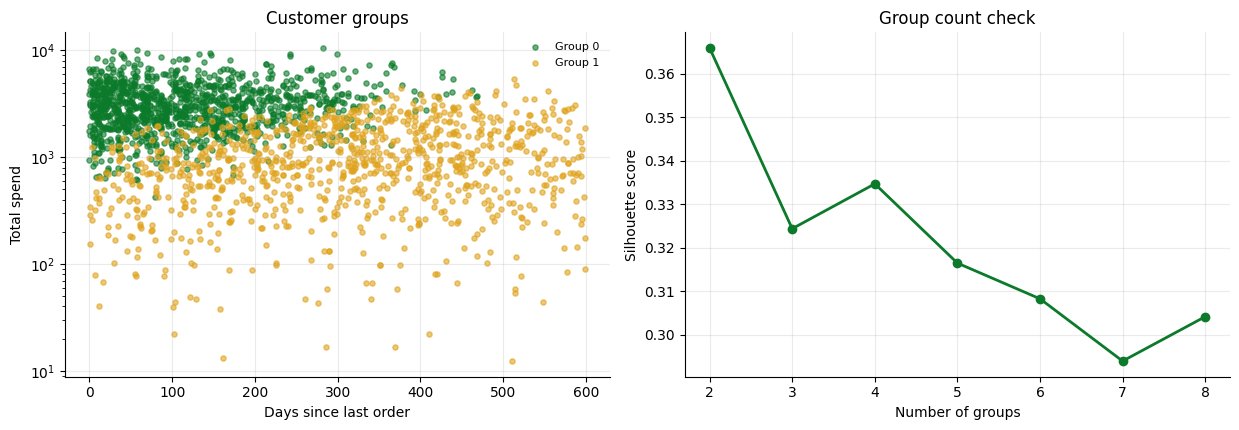

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
palette = [GREEN, GOLD, BLUE, RED, '#7A5BD0']
for c in sorted(rfm.cluster.unique()):
    g = rfm[rfm.cluster == c]
    ax[0].scatter(g.recency_days, g.monetary, s=14, alpha=.6, color=palette[c % len(palette)], label=f'Group {c}')
ax[0].set_xlabel('Days since last order'); ax[0].set_ylabel('Total spend'); ax[0].set_yscale('log')
ax[0].set_title('Customer groups'); ax[0].legend(frameon=False, fontsize=8)
sil = pd.DataFrame(scores)
ax[1].plot(sil.k, sil.silhouette, marker='o', color=GREEN, lw=2)
ax[1].set_xlabel('Number of groups'); ax[1].set_ylabel('Silhouette score'); ax[1].set_title('Group count check')
plt.tight_layout(); plt.show()

### 16.10 Forecast against actual units

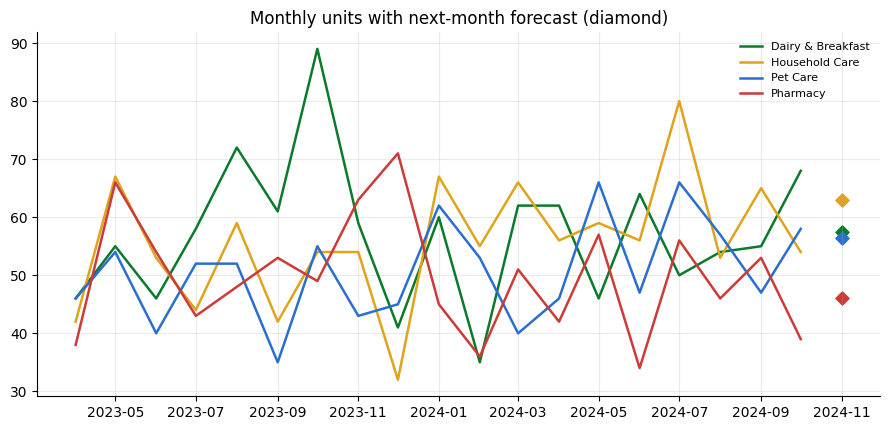

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.4))
top_cats = fc.sort_values('avg_monthly_units', ascending=False).category.head(4)
for i, cat in enumerate(top_cats):
    g = series[series.category == cat]
    ax.plot(pd.to_datetime(g.order_month), g.units, lw=1.8, color=[GREEN, GOLD, BLUE, RED][i], label=cat)
    nxt = fc.set_index('category').loc[cat, 'next_month_forecast']
    ax.scatter([pd.to_datetime(g.order_month).max() + pd.DateOffset(months=1)], [nxt],
               color=[GREEN, GOLD, BLUE, RED][i], marker='D', s=45)
ax.set_title('Monthly units with next-month forecast (diamond)'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()